In [1]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

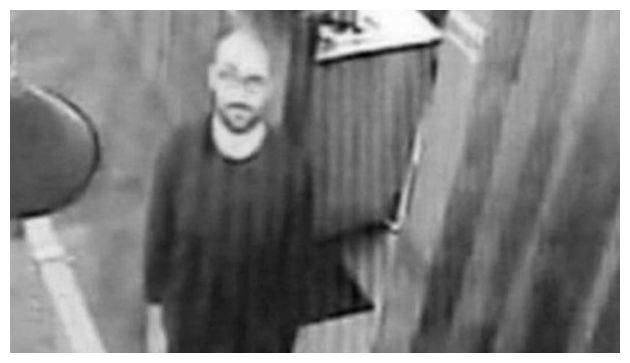

In [88]:
path_backup = 'backup.jpg'

cctv = cv2.imread(path_backup, cv2.IMREAD_GRAYSCALE)

plt.imshow(cctv, cmap='gray')
plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad = size // 2
    padded = np.pad(img, pad, mode='constant')
    h, w = img.shape[:2]
    hasil = np.zeros_like(img).astype(np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            hasil[i, j] = np.sum(region * kernel)
    return hasil

def smoothing(img):
    kernel = np.array([[1/10, 1/10, 1/10], [1/10, 1/5, 1/10], [1/10, 1/10, 1/10]])
    hasil = convolution(img, kernel)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def sharpening(img):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    hasil = convolution(img, kernel)
    return np.clip(hasil, 0, 255).astype(np.uint8)

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.median(region)
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

def tambah_citra(img1, img2):
    h, w = img1.shape[:2]
    hasil = np.zeros_like(img1)
    if len(img1.shape) == 3:
        for i in range(h):
            for j in range(w):
                for c in range(img1.shape[2]):
                    hasil[i, j, c] = np.clip(int(img1[i, j, c]) + int(img2[i, j, c]))
    else:
        for i in range(h):
            for j in range(w):
                hasil[i, j] = np.clip(int(img1[i, j]) + int(img2[i, j]))
    return hasil

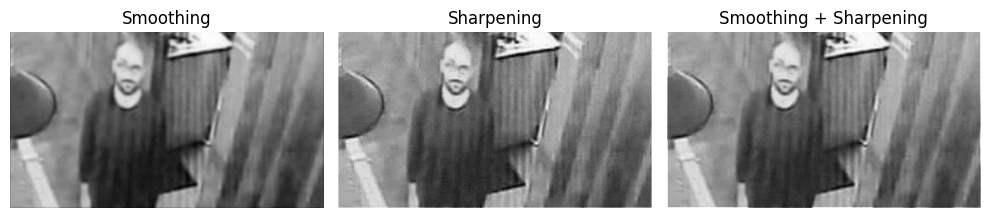

In [109]:
cctv_copy = cctv.copy()
cctv_mean = filter(cctv_copy,3, mode="mean")
cctv_median = filter(cctv_copy,3, mode="median")
cctv_modus = filter(cctv_copy,3, mode="modus")

cctv_smooth = smoothing(cctv_mean)
cctv_sharp = sharpening(cctv_median)
cctv_combine = sharpening(cctv_smooth)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 10))
ax1.imshow(cctv_smooth, cmap="gray"); ax1.set_title("Smoothing")
ax2.imshow(cctv_sharp, cmap="gray"); ax2.set_title("Sharpening")
ax3.imshow(cctv_combine, cmap="gray"); ax3.set_title("Smoothing + Sharpening")

ax1.axis("off")
ax2.axis("off")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [15]:
def normalize(img):
    img = np.abs(img)
    if np.max(img) > 0:
        img = (img / np.max(img)) * 255
    return img.astype(np.uint8)

def sobel(img):
    sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    gx = convolution(img, sx)
    gy = convolution(img, sy)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def prewitt(img):
    px = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    py = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    gx = convolution(img, px)
    gy = convolution(img, py)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def roberts(img):
    rx = np.array([[1, 0], [0, -1]])
    ry = np.array([[0, 1], [-1, 0]])
    gx = convolution(img, rx)
    gy = convolution(img, ry)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

def edge_detection(img, kernel_x, kernel_y):
    gx = convolution(img, kernel_x)
    gy = convolution(img, kernel_y)
    hasil = np.abs(gx) + np.abs(gy)
    return normalize(hasil)

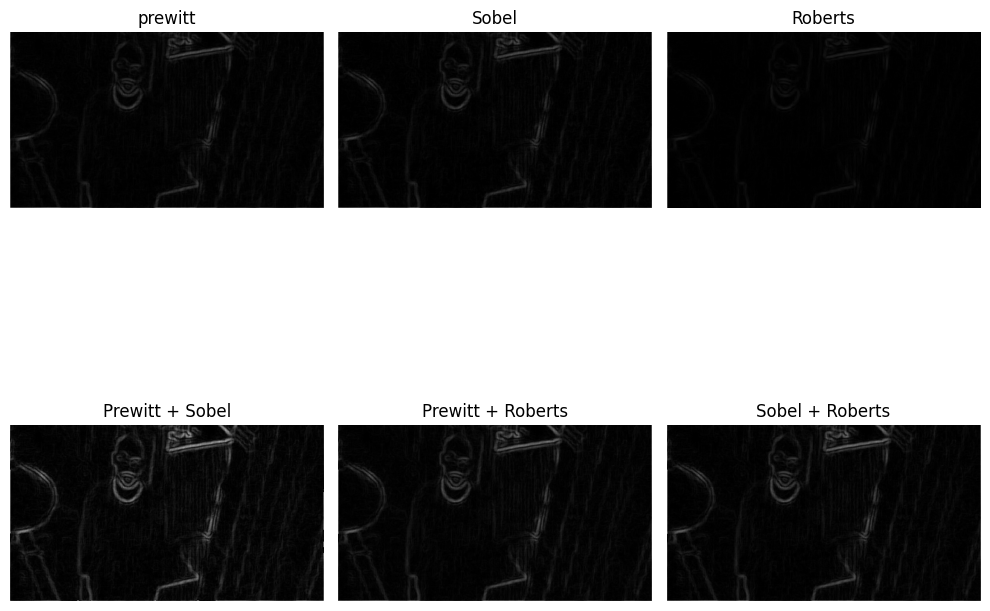

In [23]:
cctv_prewitt = prewitt(cctv_copy)
cctv_sobel = sobel(cctv_copy)
cctv_roberts = roberts(cctv_copy)
ps = tambah_citra(cctv_prewitt, cctv_sobel)
pr = tambah_citra(cctv_prewitt, cctv_roberts)
sr = tambah_citra(cctv_sobel, cctv_roberts)
prewitt_sobel = normalize(ps)
prewitt_roberts = normalize(pr)
sobel_roberts = normalize(sr)

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(10, 10))
ax1.imshow(cctv_prewitt, cmap="gray"); ax1.set_title("prewitt")
ax2.imshow(cctv_sobel, cmap="gray"); ax2.set_title("Sobel")
ax3.imshow(cctv_roberts, cmap="gray"); ax3.set_title("Roberts")
ax4.imshow(prewitt_sobel, cmap="gray"); ax4.set_title("Prewitt + Sobel")
ax5.imshow(prewitt_roberts, cmap="gray"); ax5.set_title("Prewitt + Roberts")
ax6.imshow(sobel_roberts, cmap="gray"); ax6.set_title("Sobel + Roberts")

ax1.axis("off")
ax2.axis("off")
ax3.axis("off")
ax4.axis("off")
ax5.axis("off")
ax6.axis("off")

plt.tight_layout()
plt.show()

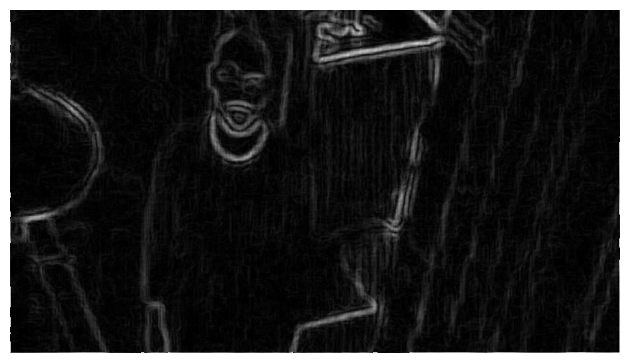

In [87]:
psr = tambah_citra(prewitt_sobel, cctv_roberts)
prewitt_sobel_roberts = normalize(psr)

plt.imshow(prewitt_sobel_roberts, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

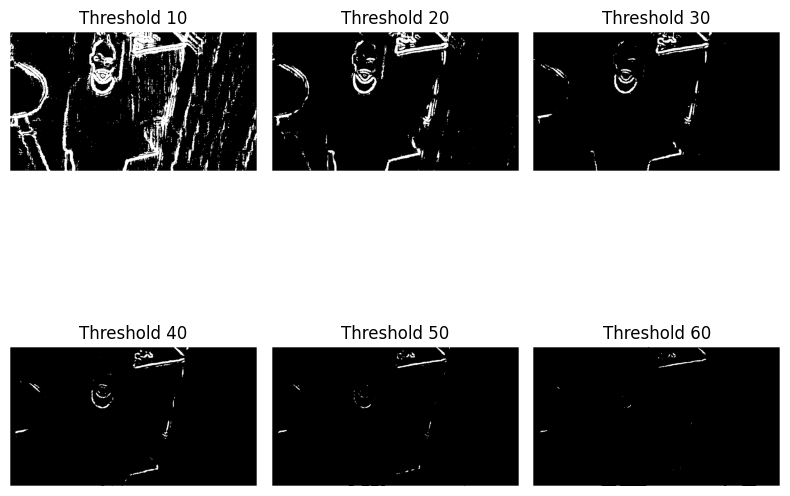

In [86]:
def threshold(img, nilai=127, maks=255):
    h, w = img.shape[:2]
    hasil = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = maks if int(img[i, j]) >= nilai else 0
    return hasil

cctv_ten = threshold(cctv_prewitt, 10)
cctv_twenty = threshold(cctv_prewitt, 20)
cctv_thirty = threshold(cctv_prewitt, 30)
cctv_fourty = threshold(cctv_prewitt, 40)
cctv_fifty = threshold(cctv_prewitt, 50)
cctv_sixty = threshold(cctv_prewitt, 60)

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(8, 8))
ax1.imshow(cctv_ten, cmap="gray"); ax1.set_title("Threshold 10")
ax2.imshow(cctv_twenty, cmap="gray"); ax2.set_title("Threshold 20")
ax3.imshow(cctv_thirty, cmap="gray"); ax3.set_title("Threshold 30")
ax4.imshow(cctv_fourty, cmap="gray"); ax4.set_title("Threshold 40")
ax5.imshow(cctv_fifty, cmap="gray"); ax5.set_title("Threshold 50")
ax6.imshow(cctv_sixty, cmap="gray"); ax6.set_title("Threshold 60")

ax1.axis("off")
ax2.axis("off")
ax3.axis("off")
ax4.axis("off")
ax5.axis("off")
ax6.axis("off")

plt.tight_layout()
plt.show()

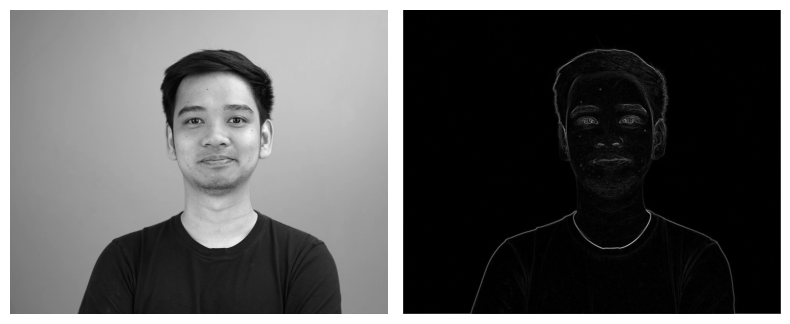

In [84]:
david_path = 'david.jpg'

david = cv2.imread(david_path)
david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)
david_edge = prewitt(david_gray)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))
ax1.imshow(david_gray, cmap="gray")
ax2.imshow(david_edge, cmap="gray")

ax1.axis("off")
ax2.axis("off")

plt.tight_layout()
plt.show()

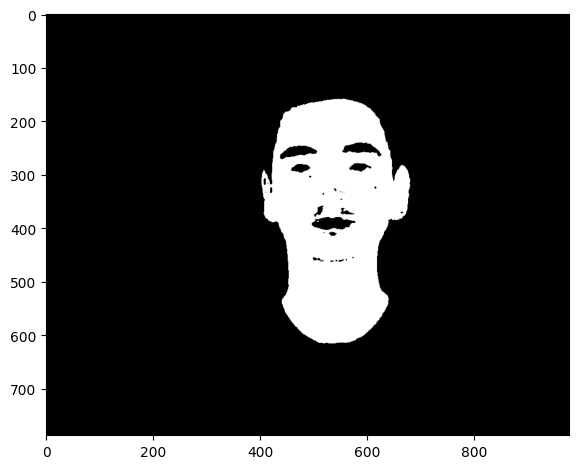

In [110]:
def split_channel(img):
    return img[:, :, 0], img[:, :, 1], img[:, :, 2]

def background_removal(image):
    R, G, B = split_channel(image)
    h, w = R.shape
    
    mask = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            if G[y, x] > R[y, x] + 10 and B[y, x] > R[y, x] + 10:
                mask[y, x] = 0
            else:
                mask[y, x] = 255
    
    mask_clean = median_filter(mask, size=3)
    
    hasil = np.zeros_like(image, dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            if mask_clean[y, x] > 127:
                hasil[y, x] = [255, 255, 255]
            else:
                hasil[y, x] = [0, 0, 0]
                
    return hasil

def invert_image(img):
    return 255 - img

david_remove = background_removal(david)
david_inv = invert_image(david_remove)


plt.imshow(david_inv, cmap="gray")
plt.tight_layout()
plt.show()

Ngakakkk